***bài 5.1 ví dụ minh họa code***

In [1]:
#Đỗ Ngọc Lâm - B22DCCN476
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks
import matplotlib.pyplot as plt


# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Chuẩn hóa và reshape về vector 784 chiều
x_train = x_train.reshape(-1, 28*28).astype("float32") / 255.0
x_test  = x_test.reshape(-1, 28*28).astype("float32") / 255.0

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (60000, 784)
Test shape: (10000, 784)


In [3]:
#Đỗ Ngọc Lâm - B22DCCN476
model_overfit = models.Sequential([
    layers.Dense(512, activation="relu", input_shape=(784,)),
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model_overfit.compile(optimizer="adam", 
                      loss="sparse_categorical_crossentropy", 
                      metrics=["accuracy"])

history_overfit = model_overfit.fit(
    x_train, y_train, 
    epochs=30, batch_size=128, 
    validation_split=0.2, 
    verbose=2
)


Epoch 1/30
375/375 - 3s - 8ms/step - accuracy: 0.9280 - loss: 0.2445 - val_accuracy: 0.9590 - val_loss: 0.1381
Epoch 2/30
375/375 - 2s - 6ms/step - accuracy: 0.9732 - loss: 0.0869 - val_accuracy: 0.9730 - val_loss: 0.0909
Epoch 3/30
375/375 - 2s - 6ms/step - accuracy: 0.9822 - loss: 0.0559 - val_accuracy: 0.9753 - val_loss: 0.0829
Epoch 4/30
375/375 - 2s - 6ms/step - accuracy: 0.9886 - loss: 0.0359 - val_accuracy: 0.9773 - val_loss: 0.0785
Epoch 5/30
375/375 - 2s - 6ms/step - accuracy: 0.9918 - loss: 0.0263 - val_accuracy: 0.9761 - val_loss: 0.0894
Epoch 6/30
375/375 - 2s - 6ms/step - accuracy: 0.9931 - loss: 0.0212 - val_accuracy: 0.9738 - val_loss: 0.0985
Epoch 7/30
375/375 - 2s - 6ms/step - accuracy: 0.9935 - loss: 0.0199 - val_accuracy: 0.9765 - val_loss: 0.1000
Epoch 8/30
375/375 - 2s - 6ms/step - accuracy: 0.9942 - loss: 0.0166 - val_accuracy: 0.9783 - val_loss: 0.0967
Epoch 9/30
375/375 - 2s - 6ms/step - accuracy: 0.9950 - loss: 0.0159 - val_accuracy: 0.9765 - val_loss: 0.0973
E

In [4]:
#Đỗ Ngọc Lâm - B22DCCN476
model_reg = models.Sequential([
    layers.Dense(512, activation="relu", input_shape=(784,),
                 kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.5),
    layers.Dense(256, activation="relu",
                 kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.5),
    layers.Dense(10, activation="softmax")
])

model_reg.compile(optimizer="adam", 
                  loss="sparse_categorical_crossentropy", 
                  metrics=["accuracy"])

es = callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history_reg = model_reg.fit(
    x_train, y_train, 
    epochs=50, batch_size=128, 
    validation_split=0.2, 
    callbacks=[es], 
    verbose=2
)


Epoch 1/50
375/375 - 3s - 8ms/step - accuracy: 0.8663 - loss: 0.5142 - val_accuracy: 0.9553 - val_loss: 0.2317
Epoch 2/50
375/375 - 2s - 6ms/step - accuracy: 0.9413 - loss: 0.2787 - val_accuracy: 0.9662 - val_loss: 0.1985
Epoch 3/50
375/375 - 2s - 6ms/step - accuracy: 0.9548 - loss: 0.2362 - val_accuracy: 0.9724 - val_loss: 0.1779
Epoch 4/50
375/375 - 2s - 6ms/step - accuracy: 0.9605 - loss: 0.2141 - val_accuracy: 0.9723 - val_loss: 0.1749
Epoch 5/50
375/375 - 2s - 6ms/step - accuracy: 0.9648 - loss: 0.1966 - val_accuracy: 0.9743 - val_loss: 0.1721
Epoch 6/50
375/375 - 2s - 6ms/step - accuracy: 0.9679 - loss: 0.1894 - val_accuracy: 0.9754 - val_loss: 0.1634
Epoch 7/50
375/375 - 2s - 6ms/step - accuracy: 0.9697 - loss: 0.1821 - val_accuracy: 0.9769 - val_loss: 0.1639
Epoch 8/50
375/375 - 2s - 5ms/step - accuracy: 0.9713 - loss: 0.1754 - val_accuracy: 0.9760 - val_loss: 0.1633
Epoch 9/50
375/375 - 2s - 5ms/step - accuracy: 0.9731 - loss: 0.1714 - val_accuracy: 0.9768 - val_loss: 0.1611
E

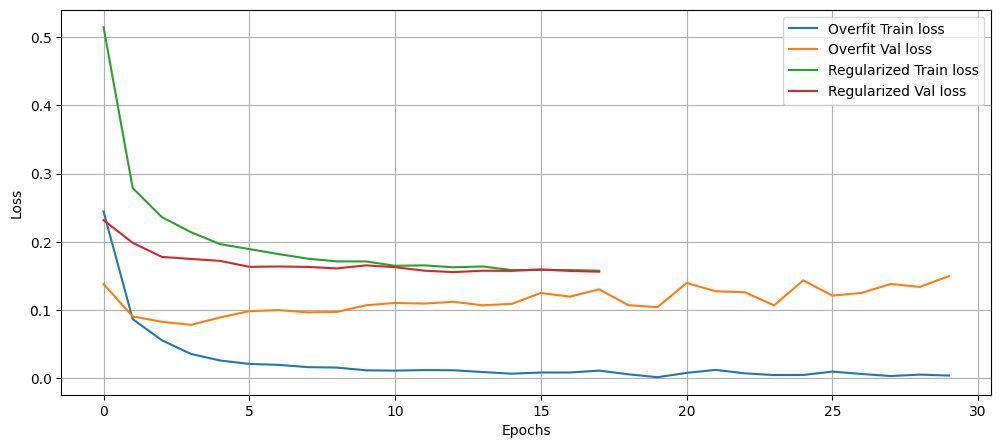

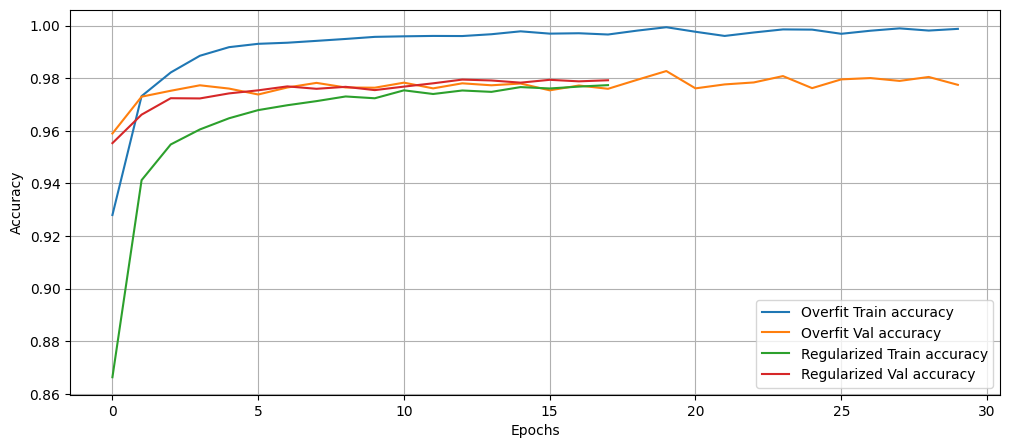

In [8]:
#Đỗ Ngọc Lâm - B22DCCN476
def plot_history(histories, key="loss"):
    plt.figure(figsize=(12,5))
    for name, history in histories:
        plt.plot(history.epoch, history.history[key],
                 label=f"{name} Train {key}")
        plt.plot(history.epoch, history.history["val_" + key],
                 label=f"{name} Val {key}")
    plt.xlabel("Epochs")
    plt.ylabel(key.capitalize())
    plt.legend()
    plt.grid(True)
    plt.show()

# Vẽ Loss
plot_history([("Overfit", history_overfit), ("Regularized", history_reg)], key="loss")
# plot_history([("Overfit", history_overfit)], key="loss")

# Vẽ Accuracy
plot_history([("Overfit", history_overfit), ("Regularized", history_reg)], key="accuracy")


***5.2 Applying Learning Rate Changing and Data Augmentation into my 4.2 ASSIGNMENT***

In [33]:
# Đỗ Ngọc Lâm - B22DCCN476
import os, math, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

# Dùng TF v1 graph mode (không Keras)
tf.compat.v1.disable_eager_execution()
np.random.seed(42); random.seed(42); tf.random.set_seed(42)

def print_bar(title):
    print("\n" + "="*20 + f" {title} " + "="*20)


In [34]:
# Đỗ Ngọc Lâm - B22DCCN476
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

def synthesize_dataset(n=4000, seed=42):
    rng = np.random.default_rng(seed)
    gender = rng.choice(["male","female"], n)
    age = rng.integers(18, 70, n)
    height_cm = np.where(gender=="male", rng.normal(172,7,n), rng.normal(160,6,n)).clip(145,200)
    activity = rng.choice(["low","medium","high"], n, p=[0.3,0.5,0.2])
    weight_kg = 50 + 0.4*(age-18) + rng.normal(0,6,n)
    weight_kg += np.where(activity=="low", 5, np.where(activity=="high",-3,0))
    bmi = weight_kg / ((height_cm/100.0)**2)
    def bmi_label(x): 
        if x<18.5: return "under"
        if x<25:   return "normal"
        return "over"
    y = np.array([bmi_label(x) for x in bmi])
    return pd.DataFrame({
        "gender":gender, "activity":activity, "age":age,
        "height_cm":height_cm, "weight_kg":weight_kg, "BMI":bmi, "label":y
    })

df = synthesize_dataset(4000)
X = df.drop(columns=["BMI","label"])
y = df["label"]

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

# OneHotEncoder: tương thích nhiều phiên bản sklearn
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)  # sklearn >= 1.2
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)         # sklearn <= 1.1

pre = ColumnTransformer([
    ("cat", ohe, cat_cols),
    ("num", StandardScaler(), num_cols),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
pre.fit(X_train)
X_train_t = pre.transform(X_train).astype(np.float32)
X_test_t  = pre.transform(X_test).astype(np.float32)

label2id   = {"under":0,"normal":1,"over":2}
y_train_id = np.array([label2id[v] for v in y_train], dtype=np.int32)
y_test_id  = np.array([label2id[v] for v in y_test],  dtype=np.int32)

feat_dim = X_train_t.shape[1]
num_classes = 3

print_bar("DATA READY")
print("feat_dim:", feat_dim, "| train:", X_train_t.shape, "| test:", X_test_t.shape)



==================== DATA READY ====================
feat_dim: 8 | train: (3200, 8) | test: (800, 8)


In [35]:
# Đỗ Ngọc Lâm - B22DCCN476
def cosine_lr_schedule(epoch, total_epochs, lr_max=1e-3, lr_min=1e-5):
    """Cosine decay từ lr_max về lr_min theo epoch (1..E)."""
    cos_inner = math.pi * epoch / float(total_epochs)
    return float(lr_min + 0.5*(lr_max - lr_min)*(1 + math.cos(cos_inner)))

def augment_batch_tabular(xb, p_feature_dropout=0.05, noise_std=0.02, seed=None):
    """Augmentation tabular: feature dropout + Gaussian jitter."""
    rng = np.random.default_rng(seed)
    xb = xb.copy()
    if p_feature_dropout > 0:
        drop_mask = rng.random(xb.shape) < p_feature_dropout
        xb[drop_mask] = 0.0
    if noise_std > 0:
        xb += rng.normal(0.0, noise_std, size=xb.shape).astype(xb.dtype)
    return xb


In [36]:
# Đỗ Ngọc Lâm - B22DCCN476
g_cnn = tf.Graph()
with g_cnn.as_default():
    Xc   = tf.compat.v1.placeholder(tf.float32, [None, feat_dim], name="X")
    yc   = tf.compat.v1.placeholder(tf.int32,   [None],           name="y")
    lr_c = tf.compat.v1.placeholder(tf.float32, shape=(),         name="lr")

    x1 = tf.expand_dims(Xc, -1)  # [B, T, 1]
    Wc1 = tf.Variable(tf.random.normal([5,1,32], stddev=0.1))
    Wc2 = tf.Variable(tf.random.normal([5,32,64], stddev=0.1))
    z = tf.nn.relu(tf.nn.conv1d(x1, Wc1, 1, "SAME"))
    z = tf.nn.relu(tf.nn.conv1d(z,  Wc2, 1, "SAME"))
    gap = tf.reduce_mean(z, axis=1)  # [B,64]

    Wo = tf.Variable(tf.random.normal([64, num_classes], stddev=0.1))
    bo = tf.Variable(tf.zeros([num_classes]))
    logits = tf.matmul(gap, Wo) + bo

    loss = tf.reduce_mean(tf.nn.sparse_softmax_cross_entropy_with_logits(labels=yc, logits=logits))
    train_op = tf.compat.v1.train.AdamOptimizer(lr_c).minimize(loss)
    preds = tf.argmax(logits, axis=1)
    acc = tf.reduce_mean(tf.cast(tf.equal(preds, tf.cast(yc, tf.int64)), tf.float32))
    init = tf.compat.v1.global_variables_initializer()

def train_cnn_sched_aug(epochs=12, batch=64):
    hist = {"loss": [], "val_acc": []}
    with tf.compat.v1.Session(graph=g_cnn) as sess:
        sess.run(init)
        n = X_train_t.shape[0]
        for ep in range(1, epochs+1):
            lr = cosine_lr_schedule(ep, epochs, 1e-3, 1e-5)
            idx = np.random.permutation(n)
            Xp, yp = X_train_t[idx], y_train_id[idx]
            losses=[]
            for i in range(0, n, batch):
                xb, yb = Xp[i:i+batch], yp[i:i+batch]
                xb_aug = augment_batch_tabular(xb, p_feature_dropout=0.05, noise_std=0.02)
                _, l = sess.run([train_op, loss], feed_dict={Xc: xb_aug, yc: yb, lr_c: lr})
                losses.append(l)
            acc_val = sess.run(acc, feed_dict={Xc: X_test_t, yc: y_test_id})
            hist["loss"].append(float(np.mean(losses))); hist["val_acc"].append(float(acc_val))
            print(f"[CNN] Ep {ep:02d} | lr={lr:.1e} | loss={np.mean(losses):.4f} | val_acc={acc_val:.3f}")
    return hist


In [37]:
# Đỗ Ngọc Lâm - B22DCCN476
def build_rnn_graph_lr(feat_dim, hidden=32, layers=2, n_classes=3):
    g = tf.Graph()
    with g.as_default():
        X = tf.compat.v1.placeholder(tf.float32, [None, feat_dim], name="X")
        y = tf.compat.v1.placeholder(tf.int32,   [None],          name="y")
        lr_r = tf.compat.v1.placeholder(tf.float32, shape=(),     name="lr")
        x_seq = tf.expand_dims(X, -1)  # [B,T,1]

        Wxh = tf.Variable(tf.random.normal([1,hidden], stddev=0.1))
        Whh = tf.Variable(tf.random.normal([hidden,hidden], stddev=0.1))
        b   = tf.Variable(tf.zeros([hidden]))

        h = tf.zeros([tf.shape(X)[0], hidden], dtype=tf.float32)
        for t in range(feat_dim):
            x_t = x_seq[:, t, :]
            h   = tf.tanh(tf.matmul(x_t, Wxh) + tf.matmul(h, Whh) + b)

        Wo = tf.Variable(tf.random.normal([hidden, n_classes], stddev=0.1))
        bo = tf.Variable(tf.zeros([n_classes]))
        logits = tf.matmul(h, Wo) + bo

        loss = tf.reduce_mean(tf.nn.sparse_softmax_cross_entropy_with_logits(labels=y, logits=logits))
        train_op = tf.compat.v1.train.AdamOptimizer(lr_r).minimize(loss)
        preds = tf.argmax(logits, axis=1)
        acc = tf.reduce_mean(tf.cast(tf.equal(preds, tf.cast(y, tf.int64)), tf.float32))
        init = tf.compat.v1.global_variables_initializer()
    return {"graph":g, "X":X, "y":y, "lr":lr_r, "loss":loss, "train_op":train_op, "acc":acc, "init":init}

def train_graph_sched_aug(gdict, epochs=12, batch=64, name="RNN"):
    hist={"loss": [], "val_acc": []}
    g = gdict["graph"]
    with tf.compat.v1.Session(graph=g) as sess:
        sess.run(gdict["init"])
        n = X_train_t.shape[0]
        for ep in range(1, epochs+1):
            lr = cosine_lr_schedule(ep, epochs, 1e-3, 1e-5)
            idx = np.random.permutation(n)
            Xp, yp = X_train_t[idx], y_train_id[idx]
            losses=[]
            for i in range(0, n, batch):
                xb, yb = Xp[i:i+batch], yp[i:i+batch]
                xb_aug = augment_batch_tabular(xb, p_feature_dropout=0.05, noise_std=0.02)
                _, l = sess.run([gdict["train_op"], gdict["loss"]],
                                feed_dict={gdict["X"]: xb_aug, gdict["y"]: yb, gdict["lr"]: lr})
                losses.append(l)
            acc_val = sess.run(gdict["acc"], feed_dict={gdict["X"]: X_test_t, gdict["y"]: y_test_id})
            hist["loss"].append(float(np.mean(losses))); hist["val_acc"].append(float(acc_val))
            print(f"[{name}] Ep {ep:02d} | lr={lr:.1e} | loss={np.mean(losses):.4f} | val_acc={acc_val:.3f}")
    return hist


In [42]:
# Đỗ Ngọc Lâm - B22DCCN476
import tensorflow as tf

def orthogonal_init(shape, scale=1.0, dtype=tf.float32, name=None):
    """
    Orthogonal initializer đúng chuẩn cho shape bất kỳ (rows x cols):
      - Tạo ma trận vuông kích thước s = max(rows, cols)
      - QR decomposition để lấy Q trực giao
      - Cắt Q về (rows x cols)
    """
    rows, cols = int(shape[0]), int(shape[1])
    s = max(rows, cols)
    a = tf.random.normal([s, s], dtype=dtype)
    # QR: a = q * r, q trực giao
    q, _ = tf.linalg.qr(a)                  # q: [s, s]
    if rows <= cols:
        q = q[:rows, :]                     # [rows, s] -> [rows, cols] vì s = cols
    else:
        q = q[:, :cols]                     # [s, cols] -> [rows, cols] vì s = rows
    return tf.Variable(scale * q, name=name, dtype=dtype)

def build_lstm_graph_manual(feat_dim, hidden=64, layers=2, n_classes=3, l2_coef=1e-4):
    """
    LSTM thuần TF Core (graph mode, không Keras/rnn_cell):
      - Unroll theo 'feat_dim' bước (coi mỗi feature là 1 timestep)
      - Gate i, f, o, g; trạng thái (c, h)
      - W_x: truncated normal, W_h: orthogonal
      - Dropout trên h qua keep_prob
      - Dense cuối + L2; Adam(lr)
    """
    g = tf.Graph()
    with g.as_default():
        X  = tf.compat.v1.placeholder(tf.float32, [None, feat_dim], name="X")
        y  = tf.compat.v1.placeholder(tf.int32,   [None],           name="y")
        lr = tf.compat.v1.placeholder(tf.float32, shape=(),         name="lr")
        kp = tf.compat.v1.placeholder_with_default(1.0, shape=(),   name="keep_prob")

        x_seq = tf.expand_dims(X, -1)  # [B, T, 1]
        B     = tf.shape(X)[0]

        # Tham số các lớp LSTM
        params = []
        in_dim = 1
        for l in range(layers):
            W_x = tf.Variable(tf.random.truncated_normal([in_dim, 4*hidden], stddev=0.1), name=f"Wx_{l}")
            W_h = orthogonal_init([hidden, 4*hidden], scale=1.0, name=f"Wh_{l}")  # SỬA init
            b   = tf.Variable(tf.zeros([4*hidden]), name=f"b_{l}")
            params.append((W_x, W_h, b))
            in_dim = hidden

        def sigmoid(z): return 1.0 / (1.0 + tf.exp(-z))

        # Khởi tạo trạng thái
        h_states = [tf.zeros([B, hidden], dtype=tf.float32) for _ in range(layers)]
        c_states = [tf.zeros([B, hidden], dtype=tf.float32) for _ in range(layers)]

        # Unroll theo T = feat_dim
        for t in range(feat_dim):
            x_t = x_seq[:, t, :]    # [B, 1]
            inp = x_t
            new_h, new_c = [], []
            for (W_x, W_h, b), h_prev, c_prev in zip(params, h_states, c_states):
                z = tf.matmul(inp, W_x) + tf.matmul(h_prev, W_h) + b  # [B, 4h]
                i, f, o, g = tf.split(z, 4, axis=1)
                i = sigmoid(i); f = sigmoid(f); o = sigmoid(o); g = tf.tanh(g)
                c = f * c_prev + i * g
                h = o * tf.tanh(c)
                # Dropout trên h (train)
                h = tf.compat.v1.nn.dropout(h, keep_prob=kp)
                new_h.append(h); new_c.append(c)
                inp = h
            h_states, c_states = new_h, new_c

        last_h = h_states[-1]  # [B, hidden]

        # Dense cuối + L2
        W_out = tf.Variable(tf.random.truncated_normal([hidden, n_classes], stddev=0.1), name="W_out")
        b_out = tf.Variable(tf.zeros([n_classes]), name="b_out")
        logits = tf.matmul(last_h, W_out) + b_out

        ce = tf.reduce_mean(tf.nn.sparse_softmax_cross_entropy_with_logits(labels=y, logits=logits))
        l2 = l2_coef * tf.nn.l2_loss(W_out)
        loss = ce + l2

        train_op = tf.compat.v1.train.AdamOptimizer(lr).minimize(loss)
        preds = tf.argmax(logits, axis=1)
        acc   = tf.reduce_mean(tf.cast(tf.equal(preds, tf.cast(y, tf.int64)), tf.float32))

        init = tf.compat.v1.global_variables_initializer()

    return {"graph":g, "X":X, "y":y, "lr":lr, "kp":kp,
            "loss":loss, "train_op":train_op, "acc":acc, "init":init}

# Đỗ Ngọc Lâm - B22DCCN476
def train_lstm_manual_sched_aug(gdict,
                                X_train_t, y_train_id, X_test_t, y_test_id,
                                epochs=16, batch=64,
                                lr_max=1e-3, lr_min=1e-5,
                                keep_prob_train=0.8,
                                p_feature_dropout=0.05, noise_std=0.02,
                                name="LSTM(Manual)"):
    """
    FIX: Lấy graph từ gdict["X"].graph để đảm bảo đúng kiểu tf.Graph,
    tránh trường hợp gdict["graph"] bị ghi đè thành SymbolicTensor.
    """
    hist={"loss": [], "val_acc": []}

    # Lấy graph “chuẩn” từ placeholder
    graph = gdict["X"].graph

    with graph.as_default():
        with tf.compat.v1.Session(graph=graph) as sess:
            sess.run(gdict["init"])
            n = X_train_t.shape[0]
            for ep in range(1, epochs+1):
                lr = cosine_lr_schedule(ep, epochs, lr_max=lr_max, lr_min=lr_min)
                idx = np.random.permutation(n)
                Xp, yp = X_train_t[idx], y_train_id[idx]
                losses=[]
                for i in range(0, n, batch):
                    xb, yb = Xp[i:i+batch], yp[i:i+batch]
                    xb_aug = augment_batch_tabular(xb, p_feature_dropout=p_feature_dropout, noise_std=noise_std)
                    _, l = sess.run([gdict["train_op"], gdict["loss"]],
                                    feed_dict={gdict["X"]: xb_aug, gdict["y"]: yb,
                                               gdict["lr"]: lr, gdict["kp"]: keep_prob_train})
                    losses.append(l)
                acc_val = sess.run(gdict["acc"],
                                   feed_dict={gdict["X"]: X_test_t, gdict["y"]: y_test_id, gdict["kp"]: 1.0})
                hist["loss"].append(float(np.mean(losses))); hist["val_acc"].append(float(acc_val))
                print(f"[{name}] Ep {ep:02d} | lr={lr:.1e} | loss={np.mean(losses):.4f} | val_acc={acc_val:.3f}")
    return hist



==================== TRAIN CNN / RNN / LSTM with LR-Schedule + Augmentation ====================
[CNN] Ep 01 | lr=9.8e-04 | loss=0.9929 | val_acc=0.579
[CNN] Ep 02 | lr=9.3e-04 | loss=0.8729 | val_acc=0.600
[CNN] Ep 03 | lr=8.6e-04 | loss=0.7338 | val_acc=0.795
[CNN] Ep 04 | lr=7.5e-04 | loss=0.5825 | val_acc=0.856
[CNN] Ep 05 | lr=6.3e-04 | loss=0.4845 | val_acc=0.873
[CNN] Ep 06 | lr=5.1e-04 | loss=0.4383 | val_acc=0.882
[CNN] Ep 07 | lr=3.8e-04 | loss=0.3979 | val_acc=0.892
[CNN] Ep 08 | lr=2.6e-04 | loss=0.3808 | val_acc=0.895
[CNN] Ep 09 | lr=1.5e-04 | loss=0.3682 | val_acc=0.896
[CNN] Ep 10 | lr=7.6e-05 | loss=0.3648 | val_acc=0.894
[CNN] Ep 11 | lr=2.7e-05 | loss=0.3655 | val_acc=0.895
[CNN] Ep 12 | lr=1.0e-05 | loss=0.3558 | val_acc=0.896
[RNN] Ep 01 | lr=9.8e-04 | loss=0.9365 | val_acc=0.707
[RNN] Ep 02 | lr=9.3e-04 | loss=0.6345 | val_acc=0.795
[RNN] Ep 03 | lr=8.6e-04 | loss=0.5296 | val_acc=0.812
[RNN] Ep 04 | lr=7.5e-04 | loss=0.4806 | val_acc=0.842
[RNN] Ep 05 | lr=6.3e-

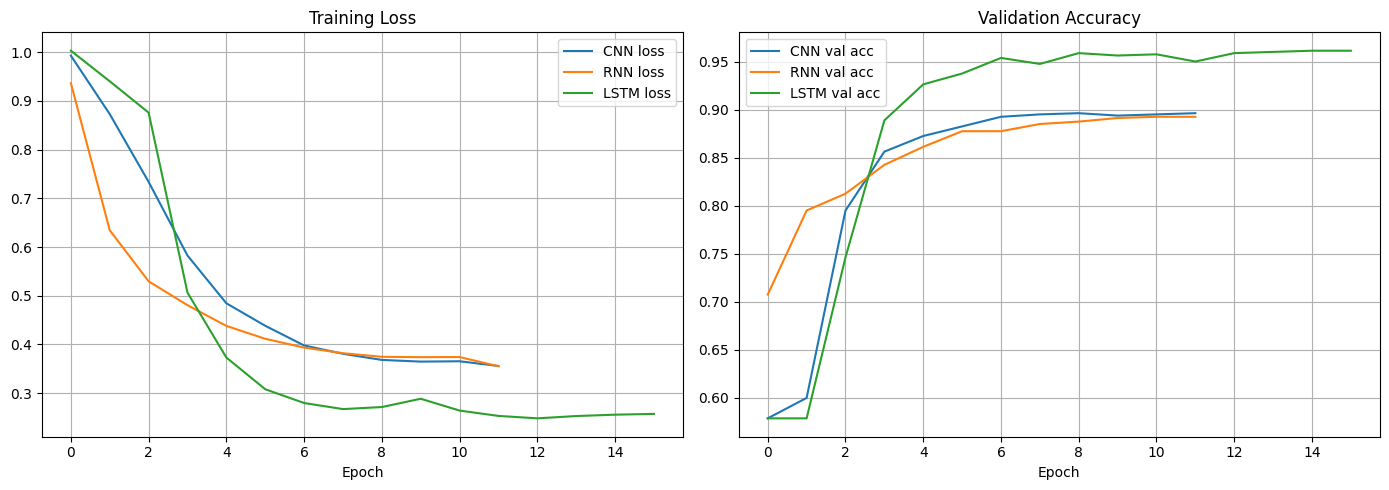


==================== FINAL VAL ACC ====================
CNN : 0.896
RNN : 0.892
LSTM: 0.961


In [43]:
# Đỗ Ngọc Lâm - B22DCCN476
print_bar("TRAIN CNN / RNN / LSTM with LR-Schedule + Augmentation")

# CNN
hist_cnn = train_cnn_sched_aug(epochs=12, batch=64)

# RNN
rnn_graph = build_rnn_graph_lr(feat_dim, hidden=32, layers=2, n_classes=num_classes)
hist_rnn  = train_graph_sched_aug(rnn_graph, epochs=12, batch=64, name="RNN")

# LSTM (manual)
lstm_graph = build_lstm_graph_manual(feat_dim, hidden=64, layers=2, n_classes=num_classes, l2_coef=1e-4)
hist_lstm  = train_lstm_manual_sched_aug(
    lstm_graph, X_train_t, y_train_id, X_test_t, y_test_id,
    epochs=16, batch=64, lr_max=1e-3, lr_min=1e-5,
    keep_prob_train=0.8, p_feature_dropout=0.05, noise_std=0.02,
    name="LSTM(Manual)"
)

# Plot learning curves
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(hist_cnn["loss"], label="CNN loss")
plt.plot(hist_rnn["loss"], label="RNN loss")
plt.plot(hist_lstm["loss"], label="LSTM loss")
plt.title("Training Loss"); plt.xlabel("Epoch"); plt.legend(); plt.grid(True)

plt.subplot(1,2,2)
plt.plot(hist_cnn["val_acc"], label="CNN val acc")
plt.plot(hist_rnn["val_acc"], label="RNN val acc")
plt.plot(hist_lstm["val_acc"], label="LSTM val acc")
plt.title("Validation Accuracy"); plt.xlabel("Epoch"); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

print_bar("FINAL VAL ACC")
print(f"CNN : {hist_cnn['val_acc'][-1]:.3f}")
print(f"RNN : {hist_rnn['val_acc'][-1]:.3f}")
print(f"LSTM: {hist_lstm['val_acc'][-1]:.3f}")


***Bài 5.4. Film review***

In [1]:
#B22DCCN476 - Đỗ Ngọc Lâm

import os, re, math, random, gc, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)


TensorFlow: 2.20.0


In [2]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Load dataset

CSV_PATH = "filmReview_1.csv"
df = pd.read_csv(CSV_PATH)

# Chuẩn hóa ngày (nếu có)
if 'review_date' in df.columns:
    df['review_date'] = pd.to_datetime(df['review_date'], errors='coerce')

display(df.head(10))
print("Rows:", len(df))
print("Columns:", df.columns.tolist())


,review_id,user_id,user_name,film_title,rating,review_text,review_date
0,1,328,user_328,Inception,1,Not my cup of tea. I struggled to finish it. R...,2015-01-03
1,2,72,user_072,Double Indemnity,4,Avoidable — wasted potential and boring in pla...,2023-03-31
2,3,217,user_217,Vertigo,1,Disappointing. Expected more based on hype. Re...,2021-05-02
3,4,309,user_309,Schindler's List,8,Brilliant — outstanding acting and a memorable...,2014-12-11
4,5,230,user_230,Shutter Island,6,"It was okay — some parts worked, some didn't. ...",2025-08-29
5,6,217,user_217,Toy Story 4,6,Average movie. Enjoyable in parts but not perf...,2012-04-17
6,7,48,user_048,The Hurt Locker,3,Not my cup of tea. I struggled to finish it. G...,2015-12-07
7,8,414,user_414,The Godfather Part II,9,Brilliant — outstanding acting and a memorable...,2018-06-28
8,9,41,user_041,Dead Poets Society,6,Solid film but forgettable after a while. Not ...,2022-12-13
9,10,99,user_099,The Apartment (1960),3,Disappointing. Expected more based on hype. No...,2011-10-16


Rows: 5000
Columns: ['review_id', 'user_id', 'user_name', 'film_title', 'rating', 'review_text', 'review_date']


In [3]:
#B22DCCN476 - Đỗ Ngọc Lâm

def clean_text(s: str) -> str:
    if not isinstance(s, str): return ""
    s = s.lower()
    s = re.sub(r"http\S+|www\S+"," ", s)
    s = re.sub(r"[^a-z0-9\s.,!?']"," ", s)
    s = re.sub(r"\s+"," ", s).strip()
    return s

assert 'review_text' in df.columns and 'rating' in df.columns, "Thiếu cột review_text hoặc rating"

df['text'] = df['review_text'].astype(str).apply(clean_text)

def map_label(r):
    try: r = float(r)
    except: return np.nan
    if r <= 3: return 0   # Negative
    if r <= 6: return 1   # Neutral
    return 2              # Positive

df['label'] = df['rating'].apply(map_label)
df = df.dropna(subset=['text','label']).reset_index(drop=True)

print(df['label'].value_counts())
display(df[['review_id','film_title','rating','label','text']].head())


label
2    3154
1    1334
0     512
Name: count, dtype: int64


,review_id,film_title,rating,label,text
0,1,Inception,1,0,not my cup of tea. i struggled to finish it. r...
1,2,Double Indemnity,4,1,avoidable wasted potential and boring in places.
2,3,Vertigo,1,0,disappointing. expected more based on hype. re...
3,4,Schindler's List,8,2,brilliant outstanding acting and a memorable s...
4,5,Shutter Island,6,1,"it was okay some parts worked, some didn't. re..."


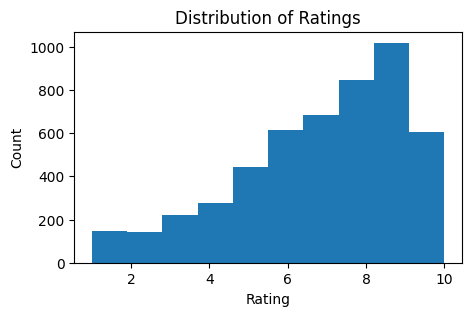

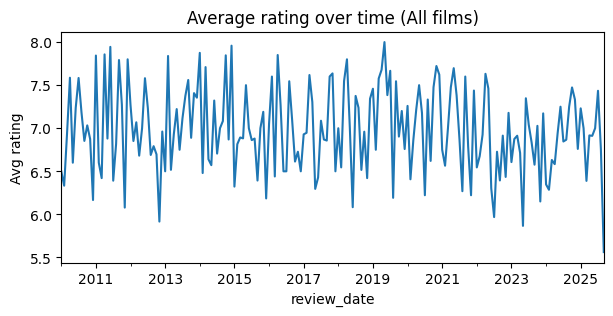

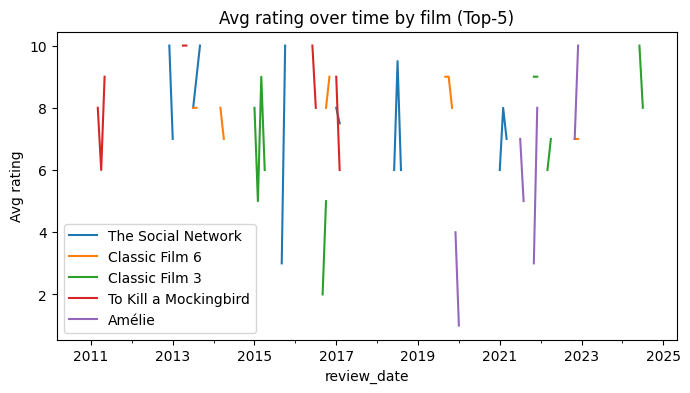

In [4]:
#B22DCCN476 - Đỗ Ngọc Lâm

plt.figure(figsize=(5,3))
df['rating'].plot(kind='hist', bins=10)
plt.title("Distribution of Ratings")
plt.xlabel("Rating"); plt.ylabel("Count"); plt.show()

if 'review_date' in df.columns and df['review_date'].notna().any():
    ts = df.dropna(subset=['review_date']).set_index('review_date').resample('M')['rating'].mean()
    if ts.notna().sum() >= 2:
        plt.figure(figsize=(7,3))
        ts.plot()
        plt.title("Average rating over time (All films)")
        plt.ylabel("Avg rating"); plt.show()

    top_films = df['film_title'].value_counts().head(5).index.tolist()
    plt.figure(figsize=(8,4))
    added=False
    for title in top_films:
        sub = df[(df['film_title']==title) & df['review_date'].notna()].copy()
        if len(sub) < 3: 
            continue
        s = sub.set_index('review_date').resample('M')['rating'].mean()
        if s.notna().sum()>=2:
            s.plot(label=title); added=True
    if added:
        plt.title("Avg rating over time by film (Top-5)")
        plt.ylabel("Avg rating"); plt.legend(); plt.show()


In [5]:
#B22DCCN476 - Đỗ Ngọc Lâm

X = df['text'].tolist()
y = df['label'].astype(int).values

X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=0.25, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test   = train_test_split(X_tmp, y_tmp, test_size=0.5, random_state=SEED, stratify=y_tmp)

print(f"Train={len(X_train)}, Val={len(X_val)}, Test={len(X_test)}")


Train=3750, Val=625, Test=625


In [6]:
#B22DCCN476 - Đỗ Ngọc Lâm
# Cell 6: Vectorizer & integer sequences  (thay thế token hóa + word2vec qua embedding trainable)

def custom_standardize(s):
    s = tf.strings.lower(s)
    s = tf.strings.regex_replace(s, r"http\S+|www\S+", " ")
    s = tf.strings.regex_replace(s, r"[^a-z0-9\s\.\,\!\?\']", " ")
    s = tf.strings.regex_replace(s, r"\s+", " ")
    return tf.strings.strip(s)

max_tokens = 30000
max_len    = 128

vectorizer = layers.TextVectorization(
    standardize=custom_standardize,
    max_tokens=max_tokens,
    output_mode="int",
    output_sequence_length=max_len
)

vectorizer.adapt(tf.constant(X_train))

# Vector hóa sang chuỗi chỉ số
Xtr_seq = vectorizer(tf.constant(X_train)).numpy()
Xva_seq = vectorizer(tf.constant(X_val)).numpy()
Xte_seq = vectorizer(tf.constant(X_test)).numpy()

vocab_size = vectorizer.vocabulary_size()
emb_dim    = 100  # "word2vector" dimension (learned during training)
print("Vocab size:", vocab_size, "| Seq shape:", Xtr_seq.shape)



Vocab size: 108 | Seq shape: (3750, 128)


In [9]:
#B22DCCN476 - Đỗ Ngọc Lâm

def build_callbacks(patience=3, monitor="val_loss"):
    es = keras.callbacks.EarlyStopping(monitor=monitor, patience=patience, restore_best_weights=True)
    rl = keras.callbacks.ReduceLROnPlateau(monitor=monitor, factor=0.5, patience=max(1, patience-1))
    return [es, rl]

def cosine_scheduler(epochs, initial_lr=1e-3):
    def schedule(epoch, lr):
        t = epoch / max(1, epochs-1)
        return 0.5*(1+math.cos(math.pi*t))*initial_lr
    return keras.callbacks.LearningRateScheduler(schedule)

def plot_history(hist, title=""):
    h = hist.history
    if 'loss' in h:
        plt.figure(figsize=(6,3))
        plt.plot(h['loss'], label='train_loss')
        if 'val_loss' in h: plt.plot(h['val_loss'], label='val_loss')
        plt.title(title or "Loss"); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.show()
    if 'accuracy' in h:
        plt.figure(figsize=(6,3))
        plt.plot(h['accuracy'], label='train_acc')
        if 'val_accuracy' in h: plt.plot(h['val_accuracy'], label='val_acc')
        plt.title(title or "Accuracy"); plt.xlabel("Epoch"); plt.ylabel("Acc"); plt.legend(); plt.show()


Epoch 1/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.7144 - loss: 0.5470 - val_accuracy: 0.7776 - val_loss: 0.3985 - learning_rate: 0.0010
Epoch 2/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8013 - loss: 0.3505 - val_accuracy: 0.7776 - val_loss: 0.3774 - learning_rate: 9.6985e-04
Epoch 3/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8120 - loss: 0.3381 - val_accuracy: 0.7776 - val_loss: 0.3733 - learning_rate: 8.8302e-04
Epoch 4/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8077 - loss: 0.3363 - val_accuracy: 0.7776 - val_loss: 0.3689 - learning_rate: 7.5000e-04
Epoch 5/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8128 - loss: 0.3309 - val_accuracy: 0.7776 - val_loss: 0.3707 - learning_rate: 5.8682e-04
Epoch 6/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8112 - loss: 0.3327 - val_accuracy: 0.7776 - val_loss: 0.3657 - learning_rate: 4.1318e-04
Epoch 7/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8155 - lo

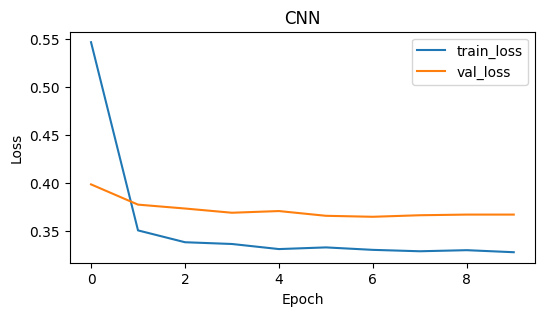

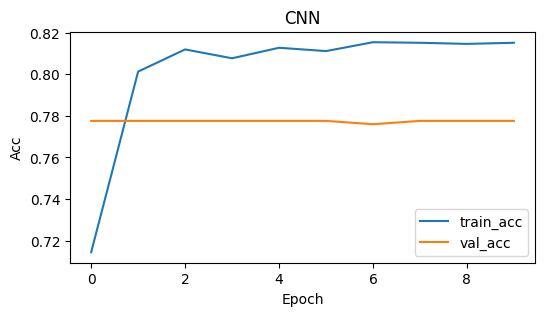

In [10]:
#B22DCCN476 - Đỗ Ngọc Lâm
# Cell 8: CNN model

num_classes = 3

def build_cnn(vocab_size, emb_dim, max_len, drop=0.3, l2=0.0):
    reg = keras.regularizers.l2(l2) if l2>0 else None
    inp = layers.Input(shape=(max_len,))
    emb = layers.Embedding(vocab_size, emb_dim, mask_zero=False)(inp)  # trainable word vectors
    x = layers.Conv1D(128, 3, activation='relu', padding='same', kernel_regularizer=reg)(emb)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(128, 5, activation='relu', padding='same', kernel_regularizer=reg)(x)
    x = layers.GlobalMaxPooling1D()(x)
    x = layers.Dropout(drop)(x)
    x = layers.Dense(128, activation='relu', kernel_regularizer=reg)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

cnn = build_cnn(vocab_size, emb_dim, max_len, drop=0.3, l2=0.0)
hist_cnn = cnn.fit(
    Xtr_seq, y_train,
    validation_data=(Xva_seq, y_val),
    epochs=10,
    batch_size=64,
    callbacks=build_callbacks(patience=3)+[cosine_scheduler(epochs=10, initial_lr=1e-3)],
    verbose=1
)

y_pred_cnn = cnn.predict(Xte_seq).argmax(1)
print("CNN Test Acc:", accuracy_score(y_test, y_pred_cnn))
print(classification_report(y_test, y_pred_cnn, digits=3))
plot_history(hist_cnn, "CNN")




Epoch 1/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.6235 - loss: 0.8968 - val_accuracy: 0.7120 - val_loss: 0.7220 - learning_rate: 0.0010
Epoch 2/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6493 - loss: 0.7808 - val_accuracy: 0.7424 - val_loss: 0.5925 - learning_rate: 0.0010
Epoch 3/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7600 - loss: 0.5267 - val_accuracy: 0.7696 - val_loss: 0.3853 - learning_rate: 0.0010
Epoch 4/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7549 - loss: 0.4728 - val_accuracy: 0.7776 - val_loss: 0.3710 - learning_rate: 0.0010
Epoch 5/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8080 - loss: 0.3514 - val_accuracy: 0.7776 - val_loss: 0.3740 - learning_rate: 0.0010
Epoch 6/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8064 - loss: 0.3405 - val_accuracy: 0.7776 - val_loss: 0.3620 - learning_rate: 0.0010
Epoch 7/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8045 - loss: 0.3409 - val_acc

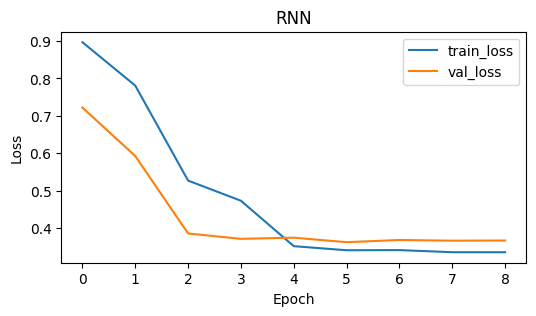

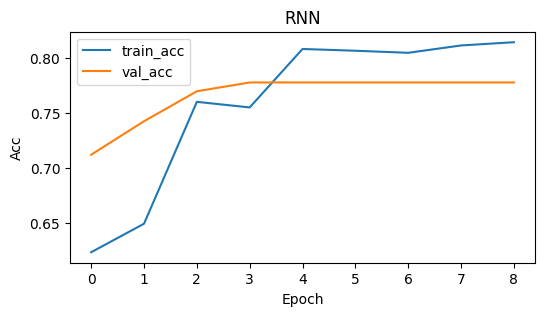

In [11]:
#B22DCCN476 - Đỗ Ngọc Lâm
# Cell 9: RNN (SimpleRNN)

def build_rnn(vocab_size, emb_dim, max_len, drop=0.3):
    inp = layers.Input(shape=(max_len,))
    emb = layers.Embedding(vocab_size, emb_dim, mask_zero=False)(inp)
    x = layers.SimpleRNN(128)(emb)
    x = layers.Dropout(drop)(x)
    x = layers.Dense(128, activation='relu')(x)
    out = layers.Dense(3, activation='softmax')(x)
    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

rnn = build_rnn(vocab_size, emb_dim, max_len, drop=0.3)
hist_rnn = rnn.fit(
    Xtr_seq, y_train,
    validation_data=(Xva_seq, y_val),
    epochs=10,
    batch_size=64,
    callbacks=build_callbacks(patience=3),
    verbose=1
)

y_pred_rnn = rnn.predict(Xte_seq).argmax(1)
print("RNN Test Acc:", accuracy_score(y_test, y_pred_rnn))
print(classification_report(y_test, y_pred_rnn, digits=3))
plot_history(hist_rnn, "RNN")


Epoch 1/12
59/59 ━━━━━━━━━━━━━━━━━━━━ 8s 101ms/step - accuracy: 0.6712 - loss: 0.9743 - val_accuracy: 0.7344 - val_loss: 0.5578 - learning_rate: 0.0010
Epoch 2/12
59/59 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - accuracy: 0.7995 - loss: 0.3942 - val_accuracy: 0.7776 - val_loss: 0.3830 - learning_rate: 0.0010
Epoch 3/12
59/59 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - accuracy: 0.8051 - loss: 0.3428 - val_accuracy: 0.7776 - val_loss: 0.3708 - learning_rate: 0.0010
Epoch 4/12
59/59 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step - accuracy: 0.8101 - loss: 0.3371 - val_accuracy: 0.7776 - val_loss: 0.3681 - learning_rate: 0.0010
Epoch 5/12
59/59 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step - accuracy: 0.8112 - loss: 0.3340 - val_accuracy: 0.7776 - val_loss: 0.3699 - learning_rate: 0.0010
Epoch 6/12
59/59 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - accuracy: 0.8123 - loss: 0.3338 - val_accuracy: 0.7776 - val_loss: 0.3684 - learning_rate: 0.0010
Epoch 7/12
59/59 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step - accuracy: 0.8125 - loss: 0.3318 - val_ac

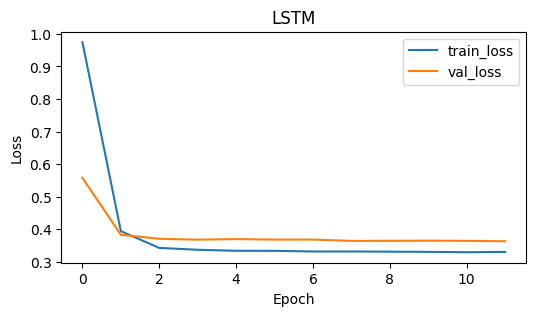

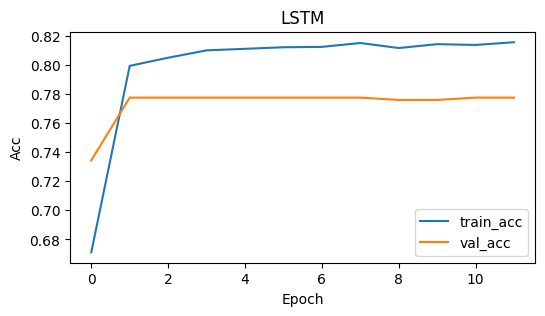

In [12]:
#B22DCCN476 - Đỗ Ngọc Lâm
# Cell 10: LSTM (BiLSTM)

def build_lstm(vocab_size, emb_dim, max_len, drop=0.4):
    inp = layers.Input(shape=(max_len,))
    emb = layers.Embedding(vocab_size, emb_dim, mask_zero=False)(inp)
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(emb)
    x = layers.GlobalMaxPooling1D()(x)
    x = layers.Dropout(drop)(x)
    x = layers.Dense(128, activation='relu')(x)
    out = layers.Dense(3, activation='softmax')(x)
    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

lstm = build_lstm(vocab_size, emb_dim, max_len, drop=0.4)
hist_lstm = lstm.fit(
    Xtr_seq, y_train,
    validation_data=(Xva_seq, y_val),
    epochs=12,
    batch_size=64,
    callbacks=build_callbacks(patience=4),
    verbose=1
)

y_pred_lstm = lstm.predict(Xte_seq).argmax(1)
print("LSTM Test Acc:", accuracy_score(y_test, y_pred_lstm))
print(classification_report(y_test, y_pred_lstm, digits=3))
plot_history(hist_lstm, "LSTM")


In [19]:
#B22DCCN476 - Đỗ Ngọc Lâm
# Cell 11a: Setup BERT with tf-keras (no torch)

import os
os.environ["KERAS_BACKEND"] = "tensorflow"  # bảo đảm tf-keras dùng backend TF

use_bert = True
try:
    # Dùng tf-keras thay vì keras 3 để đồng bộ với transformers
    import tf_keras as tk
    from tf_keras import optimizers as tk_optim, losses as tk_losses, metrics as tk_metrics, callbacks as tk_callbacks

    from transformers import AutoTokenizer, TFAutoModelForSequenceClassification

    bert_model_name = "bert-base-uncased"
    tokenizer = AutoTokenizer.from_pretrained(bert_model_name)

    def encode_texts(texts, tokenizer, max_len=128):
        return tokenizer(
            texts,
            truncation=True,
            padding="max_length",
            max_length=max_len,
            return_tensors="tf"
        )

    Xtr_enc = encode_texts(X_train, tokenizer)
    Xva_enc = encode_texts(X_val,   tokenizer)
    Xte_enc = encode_texts(X_test,  tokenizer)

    ytr = tf.convert_to_tensor(y_train)
    yva = tf.convert_to_tensor(y_val)
    yte = tf.convert_to_tensor(y_test)

except Exception as e:
    print("Không thể chuẩn bị BERT (tf-keras). Bỏ qua phần BERT.\nChi tiết:", e)
    use_bert = False


All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/3

235/235 [==============================] - 1068s 4s/step - loss: 0.4161 - accuracy: 0.7803 - val_loss: 0.3905 - val_accuracy: 0.7776
Epoch 2/3
235/235 [==============================] - 1034s 4s/step - loss: 0.3430 - accuracy: 0.8112 - val_loss: 0.3658 - val_accuracy: 0.7776
Epoch 3/3
20/20 [==============================] - 50s 2s/step
BERT Test Acc: 0.7888
              precision    recall  f1-score   support

           0      0.598     1.000     0.749        64
           1      0.582     0.743     0.653       167
           2      1.000     0.774     0.873       394

    accuracy                          0.789       625
   macro avg      0.727     0.839     0.758       625
weighted avg      0.847     0.789     0.801       625



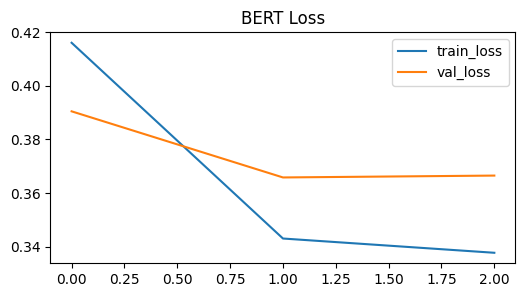

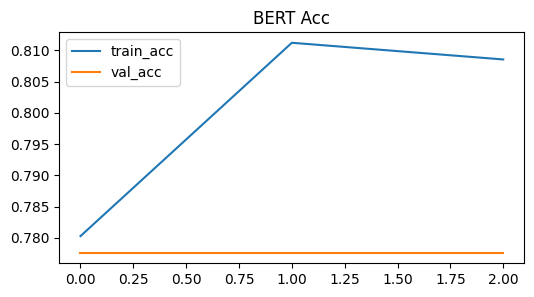

In [20]:
#B22DCCN476 - Đỗ Ngọc Lâm
# Cell 11b: Train & evaluate BERT (tf-keras only)

if use_bert:
    try:
        bert = TFAutoModelForSequenceClassification.from_pretrained(
            "bert-base-uncased", num_labels=3
        )

        # Dùng optimizer/loss/metrics của tf-keras để tránh lỗi "Could not interpret optimizer identifier"
        optimizer = tk_optim.Adam(learning_rate=3e-5)
        loss_fn   = tk_losses.SparseCategoricalCrossentropy(from_logits=True)
        metrics   = [tk_metrics.SparseCategoricalAccuracy(name="accuracy")]

        bert.compile(optimizer=optimizer, loss=loss_fn, metrics=metrics)

        cb = [tk_callbacks.EarlyStopping(monitor="val_loss", patience=1, restore_best_weights=True)]
        hist_bert = bert.fit(
            dict(Xtr_enc),
            ytr,
            validation_data=(dict(Xva_enc), yva),
            epochs=3,
            batch_size=16,
            callbacks=cb,
            verbose=1
        )

        logits = bert.predict(dict(Xte_enc)).logits
        y_pred_bert = logits.argmax(axis=1)
        from sklearn.metrics import classification_report, accuracy_score
        print("BERT Test Acc:", accuracy_score(y_test, y_pred_bert))
        print(classification_report(y_test, y_pred_bert, digits=3))

        # Vẽ learning curve
        import matplotlib.pyplot as plt
        plt.figure(figsize=(6,3)); plt.plot(hist_bert.history['loss'], label='train_loss'); plt.plot(hist_bert.history['val_loss'], label='val_loss'); plt.title("BERT Loss"); plt.legend(); plt.show()
        plt.figure(figsize=(6,3)); plt.plot(hist_bert.history['accuracy'], label='train_acc'); plt.plot(hist_bert.history['val_accuracy'], label='val_acc'); plt.title("BERT Acc"); plt.legend(); plt.show()

    except Exception as e:
        print("Không thể train/chạy BERT với tf-keras. Bỏ qua phần BERT.\nChi tiết:", e)
        use_bert = False


In [21]:
#B22DCCN476 - Đỗ Ngọc Lâm
# Cell 12: Compare models & overfitting hints

def eval_and_print(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    print(f"[{name}] Test Acc = {acc:.4f}")
    print(classification_report(y_true, y_pred, digits=3))
    return acc

scores = {}
scores['CNN']  = eval_and_print("CNN",  y_test, y_pred_cnn)
scores['RNN']  = eval_and_print("RNN",  y_test, y_pred_rnn)
scores['LSTM'] = eval_and_print("LSTM", y_test, y_pred_lstm)

if 'y_pred_bert' in globals():
    scores['BERT'] = eval_and_print("BERT", y_test, y_pred_bert)

print("\nGợi ý phát hiện overfitting:")
print("- train_loss ↓ nhưng val_loss ↑ hoặc đứng yên sau vài epoch → overfitting.")
print("- train_acc >> val_acc (khoảng cách lớn) → overfitting.")

print("\nKỹ thuật khắc phục (đã dùng/khuyến nghị):")
print("- EarlyStopping, ReduceLROnPlateau, Cosine LR schedule.")
print("- Dropout (0.3–0.6), L2 regularization (1e-4 → 5e-4).")
print("- Tăng dữ liệu/augmentation văn bản (synonym replace, deletion, swap).")
print("- Với BERT: LR 2e-5~5e-5, batch 16~32, epochs 3~5, gradient clipping.")


[CNN] Test Acc = 0.7760
              precision    recall  f1-score   support

           0      0.598     1.000     0.749        64
           1      0.566     0.695     0.624       167
           2      0.974     0.774     0.863       394

    accuracy                          0.776       625
   macro avg      0.713     0.823     0.745       625
weighted avg      0.827     0.776     0.787       625

[RNN] Test Acc = 0.7888
              precision    recall  f1-score   support

           0      0.598     1.000     0.749        64
           1      0.582     0.743     0.653       167
           2      1.000     0.774     0.873       394

    accuracy                          0.789       625
   macro avg      0.727     0.839     0.758       625
weighted avg      0.847     0.789     0.801       625

[LSTM] Test Acc = 0.7888
              precision    recall  f1-score   support

           0      0.598     1.000     0.749        64
           1      0.582     0.743     0.653       167
  

Epoch 1/12
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6371 - loss: 0.7964 - val_accuracy: 0.7376 - val_loss: 0.5533 - learning_rate: 5.0000e-04
Epoch 2/12
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7605 - loss: 0.4907 - val_accuracy: 0.7776 - val_loss: 0.4783 - learning_rate: 4.8987e-04
Epoch 3/12
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7981 - loss: 0.4300 - val_accuracy: 0.7776 - val_loss: 0.4390 - learning_rate: 4.6031e-04
Epoch 4/12
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8019 - loss: 0.4115 - val_accuracy: 0.7776 - val_loss: 0.4314 - learning_rate: 4.1372e-04
Epoch 5/12
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8069 - loss: 0.4024 - val_accuracy: 0.7776 - val_loss: 0.4258 - learning_rate: 3.5385e-04
Epoch 6/12
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8096 - loss: 0.3935 - val_accuracy: 0.7760 - val_loss: 0.4233 - learning_rate: 2.8558e-04
Epoch 7/12
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8112 

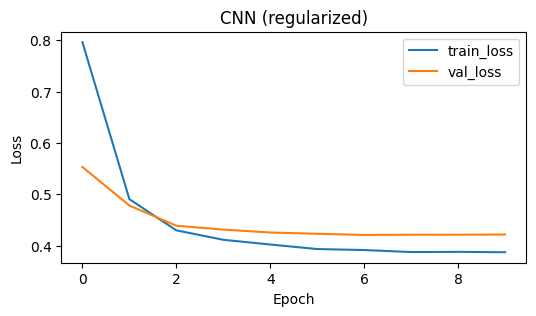

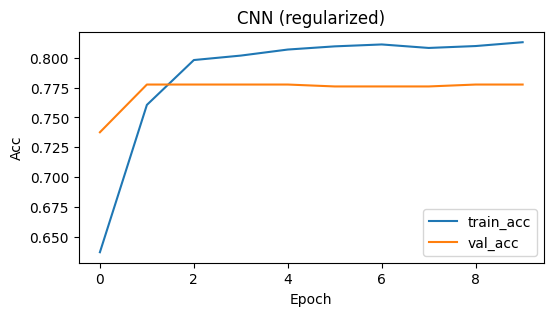

In [22]:
#B22DCCN476 - Đỗ Ngọc Lâm
# Cell 13: Regularized CNN (nếu thấy overfitting)

def build_cnn_regularized(vocab_size, emb_dim, max_len, drop=0.6, l2=2e-4):
    reg = keras.regularizers.l2(l2)
    inp = layers.Input(shape=(max_len,))
    emb = layers.Embedding(vocab_size, emb_dim, mask_zero=False)(inp)
    x = layers.Conv1D(128, 3, activation='relu', padding='same', kernel_regularizer=reg)(emb)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(128, 5, activation='relu', padding='same', kernel_regularizer=reg)(x)
    x = layers.GlobalMaxPooling1D()(x)
    x = layers.Dropout(drop)(x)
    x = layers.Dense(128, activation='relu', kernel_regularizer=reg)(x)
    out = layers.Dense(3, activation='softmax')(x)
    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(5e-4),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

cnn_reg = build_cnn_regularized(vocab_size, emb_dim, max_len, drop=0.6, l2=2e-4)
hist_cnn_reg = cnn_reg.fit(
    Xtr_seq, y_train,
    validation_data=(Xva_seq, y_val),
    epochs=12,
    batch_size=64,
    callbacks=[cosine_scheduler(epochs=12, initial_lr=5e-4), keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)],
    verbose=1
)

y_pred_cnn_reg = cnn_reg.predict(Xte_seq).argmax(1)
print("CNN (regularized) Test Acc:", accuracy_score(y_test, y_pred_cnn_reg))
print(classification_report(y_test, y_pred_cnn_reg, digits=3))
plot_history(hist_cnn_reg, "CNN (regularized)")


Epoch 1/8
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.6915 - loss: 0.5878 - val_accuracy: 0.7376 - val_loss: 0.4466 - learning_rate: 0.0010
Epoch 2/8
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7987 - loss: 0.3853 - val_accuracy: 0.7776 - val_loss: 0.3865 - learning_rate: 0.0010
Epoch 3/8
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8027 - loss: 0.3478 - val_accuracy: 0.7776 - val_loss: 0.3718 - learning_rate: 0.0010
Epoch 4/8
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8088 - loss: 0.3374 - val_accuracy: 0.7776 - val_loss: 0.3683 - learning_rate: 0.0010
Epoch 5/8
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8088 - loss: 0.3333 - val_accuracy: 0.7776 - val_loss: 0.3721 - learning_rate: 0.0010
Epoch 6/8
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8160 - loss: 0.3308 - val_accuracy: 0.7776 - val_loss: 0.3646 - learning_rate: 5.0000e-04
Epoch 7/8
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8171 - loss: 0.3292 - val_accura

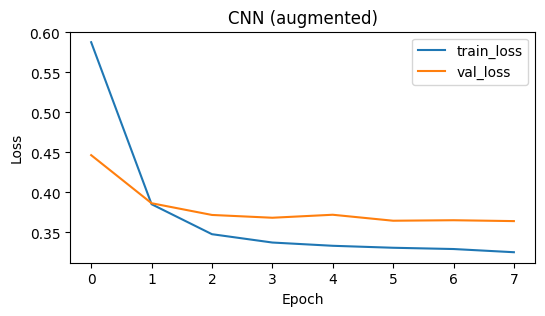

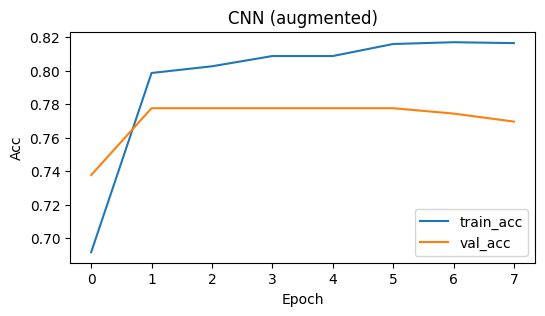

In [23]:
#B22DCCN476 - Đỗ Ngọc Lâm
# Cell 14: Simple text augmentation (optional)

def aug_text(s, p_del=0.15, p_swap=0.10):
    toks = s.split()
    # deletion
    if len(toks)>3 and p_del>0:
        toks = [w for w in toks if random.random()>p_del] or toks
    # swap
    if len(toks)>3 and random.random()<p_swap:
        i,j = random.sample(range(len(toks)), 2)
        toks[i], toks[j] = toks[j], toks[i]
    return " ".join(toks)

# Tạo bản tăng cường của train (30%)
aug_ratio = 0.30
n = len(X_train)
idxs = np.random.choice(n, int(n*aug_ratio), replace=False)
X_train_aug = X_train[:]
for i in idxs:
    X_train_aug[i] = aug_text(X_train_aug[i])

# Vector hóa lại & train nhanh 1 mô hình thử
Xtr_seq_aug = vectorizer(tf.constant(X_train_aug)).numpy()

cnn_aug = build_cnn(vocab_size, emb_dim, max_len, drop=0.4, l2=0.0)
hist_cnn_aug = cnn_aug.fit(
    Xtr_seq_aug, y_train,
    validation_data=(Xva_seq, y_val),
    epochs=8,
    batch_size=64,
    callbacks=build_callbacks(patience=2),
    verbose=1
)

y_pred_cnn_aug = cnn_aug.predict(Xte_seq).argmax(1)
print("CNN (augmented) Test Acc:", accuracy_score(y_test, y_pred_cnn_aug))
print(classification_report(y_test, y_pred_cnn_aug, digits=3))
plot_history(hist_cnn_aug, "CNN (augmented)")
